# Load all datasets

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
room_conditions = pd.read_csv('../data/raw/room_conditions.csv')
room_conditions.head()


,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,140,02/02/15 14:19,23.7000,26.272,585.200000,749.200000,0.004764,1
1,141,02/02/15 14:19,23.7180,26.290,578.400000,760.400000,0.004773,1
2,142,02/02/15 14:21,23.7300,26.230,572.666667,769.666667,0.004765,1
3,143,02/02/15 14:22,23.7225,26.125,493.750000,774.750000,0.004744,1
4,144,02/02/15 14:23,23.7540,26.200,488.600000,779.000000,0.004767,1


In [4]:
data = room_conditions.copy()

# drop id
data = data.drop('id', axis=1)

# drop occupancy column
data = data.drop('Occupancy', axis=1)

# drop humidity ratio column
data = data.drop('HumidityRatio', axis=1)

# Rename data to Date
data = data.rename(columns={'date': 'Date'})

data.head()

,Date,Temperature,Humidity,Light,CO2
0,02/02/15 14:19,23.7000,26.272,585.200000,749.200000
1,02/02/15 14:19,23.7180,26.290,578.400000,760.400000
2,02/02/15 14:21,23.7300,26.230,572.666667,769.666667
3,02/02/15 14:22,23.7225,26.125,493.750000,774.750000
4,02/02/15 14:23,23.7540,26.200,488.600000,779.000000


In [5]:
data

,Date,Temperature,Humidity,Light,CO2
0,02/02/15 14:19,23.700000,26.272000,585.200000,749.200000
1,02/02/15 14:19,23.718000,26.290000,578.400000,760.400000
2,02/02/15 14:21,23.730000,26.230000,572.666667,769.666667
3,02/02/15 14:22,23.722500,26.125000,493.750000,774.750000
4,02/02/15 14:23,23.754000,26.200000,488.600000,779.000000
...,...,...,...,...,...
2660,02/04/15 10:38,24.290000,25.700000,808.000000,1150.250000
2661,02/04/15 10:40,24.330000,25.736000,809.800000,1129.200000
2662,02/04/15 10:40,24.330000,25.700000,817.000000,1125.800000
2663,02/04/15 10:41,24.356667,25.700000,813.000000,1123.000000


In [6]:
# Shape of data
print(f'Shape of data: {data.shape}')

Shape of data: (2665, 5)


Now we can plot how many sessions there would be depending on how much time we consider enough to start a new session rather than be considered the old one



In [7]:
for threshold_new_session_min in [5, 10, 15, 20, 30]:
    # Calculate the time difference between consecutive measurements
    data['Date'] = pd.to_datetime(data['Date'])
    data['time_diff'] = data['Date'].diff().dt.total_seconds() / 60.0  # Convert to minutes

    # Identify new sessions based on the threshold
    data['new_session'] = data['time_diff'] > threshold_new_session_min

    # Count the number of sessions
    num_sessions = data['new_session'].sum() + 1  # Add 1 for the first session
    print(f'Threshold for new session: {threshold_new_session_min} minutes - Number of sessions: {num_sessions}')
    
# drop time_diff and new_session columns
data = data.drop(['time_diff', 'new_session'], axis=1)

Threshold for new session: 5 minutes - Number of sessions: 1
Threshold for new session: 10 minutes - Number of sessions: 1
Threshold for new session: 15 minutes - Number of sessions: 1
Threshold for new session: 20 minutes - Number of sessions: 1
Threshold for new session: 30 minutes - Number of sessions: 1


/tmp/ipykernel_68484/871064758.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


So yeah, it has been running for 2 days straight, no difference in sessions. 

# Exploration

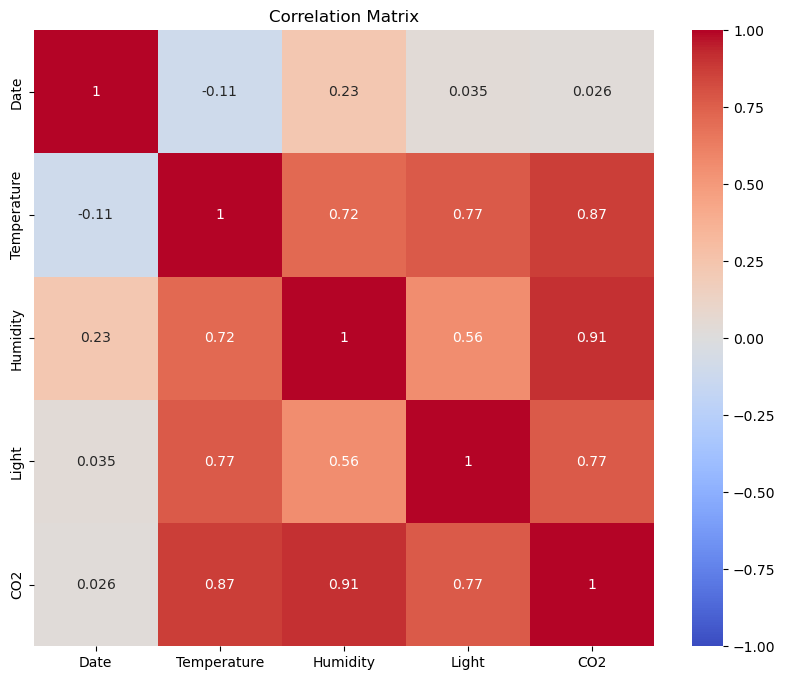

In [8]:
# Correlation matrix
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

The correlation matrix shows issues with the data - as it was perhaps all taken at the same time in the same place, we can see that all the features (except date) are highly correlated. At least because we don't have the target here, we can rely on regularization to handle this issue but nevertheless, it is something to be considered. 

# Linearization of data

When we take into account a segment of size, fx 30 min, we get a rectangular data frame out of which we only predict one value - rating of the conditions. In order to simplify the features, we compress variables into simpler representations. For example instead of taking 10 measurements of temperature, we introduce a feature like temp_max_30min, and similar. 

In [9]:
data.head()

,Date,Temperature,Humidity,Light,CO2
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000
1,2015-02-02 14:19:00,23.7180,26.290,578.400000,760.400000
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000


Features that we will have:
- max_30min
- min_30min
- mean_30min
- trend_30min (slope of the line fitted to the data in the 30 min segment)
- std_30min (standard deviation of the measurements in the 30 min segment)

In [10]:
data_linear = data.copy()

# take overlapping 30 min segments and calculate max, min, mean, trend, and std for each sensor variable
data_linear['Date'] = pd.to_datetime(data_linear['Date'], format='%m/%d/%y %H:%M')
data_linear = data_linear.set_index('Date').sort_index()

sensor_columns = ['Temperature', 'Humidity', 'Light', 'CO2']

def trend_30min(values):
    values = values.dropna()
    if len(values) < 2:
        return 0.0

    minutes_since_start = (values.index - values.index[0]).total_seconds() / 60.0
    if minutes_since_start.max() == 0:
        return 0.0
    return np.polyfit(minutes_since_start, values.to_numpy(), 1)[0]

data_linear = data_linear[sensor_columns].rolling('30min').agg(['max', 'min', 'mean', trend_30min, 'std']).dropna()

# flatten the aggregation MultiIndex into model-friendly feature names
feature_prefix = {
    'Temperature': 'Temp',
    'Humidity': 'Humidity',
    'Light': 'Light',
    'CO2': 'CO2',
}
feature_names = {
    'max': 'max30min',
    'min': 'min30min',
    'mean': 'mean30min',
    'trend_30min': 'trend30min',
    'std': 'std30min',
}
data_linear.columns = [f'{feature_names[stat]}{feature_prefix[column]}' for column, stat in data_linear.columns]
data_linear = data_linear.reset_index(drop=True)
data_linear

,max30minTemp,min30minTemp,mean30minTemp,trend30minTemp,std30minTemp,max30minHumidity,min30minHumidity,mean30minHumidity,trend30minHumidity,std30minHumidity,max30minLight,min30minLight,mean30minLight,trend30minLight,std30minLight,max30minCO2,min30minCO2,mean30minCO2,trend30minCO2,std30minCO2
0,23.718000,23.700,23.709000,0.000000,0.012728,26.290000,26.272000,26.281000,0.000000,0.012728,585.2,578.400000,581.800000,0.000000,4.808326,760.400000,749.2,754.800000,0.000000,7.919596
1,23.730000,23.700,23.716000,0.010500,0.015100,26.290000,26.230000,26.264000,-0.025500,0.030790,585.2,572.666667,578.755556,-4.566667,6.274227,769.666667,749.2,759.755556,7.433333,10.248541
2,23.730000,23.700,23.717625,0.005833,0.012750,26.290000,26.125000,26.229250,-0.046111,0.073907,585.2,493.750000,557.504167,-23.842593,42.810397,774.750000,749.2,763.504167,6.824074,11.235216
3,23.754000,23.700,23.724900,0.009328,0.019661,26.290000,26.125000,26.223400,-0.029344,0.065328,585.2,488.600000,543.723333,-24.416146,48.208966,779.000000,749.2,766.603333,6.261979,11.945573
4,23.760000,23.700,23.730750,0.010916,0.022684,26.290000,26.125000,26.229500,-0.018327,0.060312,585.2,488.600000,547.880556,-15.849340,44.305513,790.000000,749.2,770.502778,7.309736,14.331482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,24.290000,23.700,24.044676,0.020255,0.183873,26.566667,25.700000,26.106490,-0.018664,0.238769,808.0,737.800000,776.741667,2.088448,19.819089,1213.750000,1119.0,1157.614921,0.094970,22.734764
2660,24.330000,23.718,24.065676,0.019760,0.179063,26.566667,25.700000,26.093690,-0.021119,0.248129,809.8,740.500000,779.141667,2.036722,19.293283,1213.750000,1122.5,1157.954921,-0.371337,22.207519
2661,24.330000,23.718,24.074203,0.019600,0.182342,26.566667,25.700000,26.080991,-0.021596,0.253999,817.0,740.500000,780.362903,2.082073,20.150858,1213.750000,1122.5,1156.917665,-0.526755,22.585119
2662,24.356667,23.745,24.094805,0.019063,0.176749,26.566667,25.700000,26.068088,-0.023812,0.263002,817.0,740.500000,782.556452,2.056355,19.872255,1213.750000,1122.5,1156.904762,-0.943580,22.605012


# Mocking Target

The plan is to create a deterministic function that asses the room conditions based on some personality profile and then outputs the rating of the current conditions of the room on a scale. Then random noise is added to this and in general this gives the target variable for the model to predict. 

In [11]:
def penalty_outside_range(value, low, high, tolerance):
    if value < low:
        return (low - value) / tolerance
    if value > high:
        return (value - high) / tolerance
    return 0.0


def mock_study_suitability_rating(row, add_noise=True, rng=None):
    score = 5.0

    # Comfortable study conditions: mild temperature, moderate humidity,
    # low CO2, enough light, and stable readings over the 30 min segment.
    score -= 1.2 * penalty_outside_range(row['mean30minTemp'], 20, 24, 3)
    score -= 0.5 * max(0, row['max30minTemp'] - row['min30minTemp'] - 2)
    score -= 0.8 * penalty_outside_range(row['mean30minHumidity'], 35, 60, 15)
    score -= 1.4 * penalty_outside_range(row['mean30minCO2'], 0, 1000, 500)
    score -= 0.9 * penalty_outside_range(row['mean30minLight'], 300, 750, 250)

    # Penalize unstable or clearly worsening conditions.
    score -= min(row['std30minTemp'] / 1.5, 0.7)
    score -= min(row['std30minCO2'] / 350, 0.7)
    score -= min(abs(row['trend30minTemp']) / 0.08, 0.5)
    score -= min(max(row['trend30minCO2'], 0) / 25, 0.7)

    if add_noise:
        rng = np.random.default_rng(42) if rng is None else rng
        score += rng.normal(0, 0.25)

    return int(np.clip(np.rint(score), 1, 5))


def assess_room_conditions(data, seed=42, add_noise=True):
    rng = np.random.default_rng(seed)
    rated_data = data.copy()
    rated_data['rating'] = rated_data.apply(
        lambda row: mock_study_suitability_rating(row, add_noise=add_noise, rng=rng),
        axis=1,
    )
    return rated_data


data_linear = assess_room_conditions(data_linear)
data_linear['rating'].value_counts().sort_index()


rating
2       8
3    1416
4    1174
5      66
Name: count, dtype: int64

TODO: most data points are 3/4, we need to simulate worse and better conditions as well as different personalities

# Save

In [12]:
# save to data/mock/new/data.csv
data_linear.to_csv('../data/mock/new/data.csv', index=False)

# TODO
Soemthing is weird about the number of rows in linear data, it is too much somehow, we need to check that.